In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading the dataset and Defining paths

In [2]:
dataset_path = "/content/drive/MyDrive/ml_project/split_dataset"

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"
test_dir = dataset_path + "/test"

In [3]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2269 files belonging to 3 classes.
Found 485 files belonging to 3 classes.
Found 505 files belonging to 3 classes.


In [5]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['foot-and-mouth', 'healthy', 'lumpy']


In [6]:
print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Testing batches:", len(test_ds))

Training batches: 71
Validation batches: 16
Testing batches: 16


Preprocessing & Normalization

In [13]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

In [9]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [10]:
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", images.numpy().min())
    print("Maximum pixel value:", images.numpy().max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Data Augmantation layer

In [11]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

testing augmantation


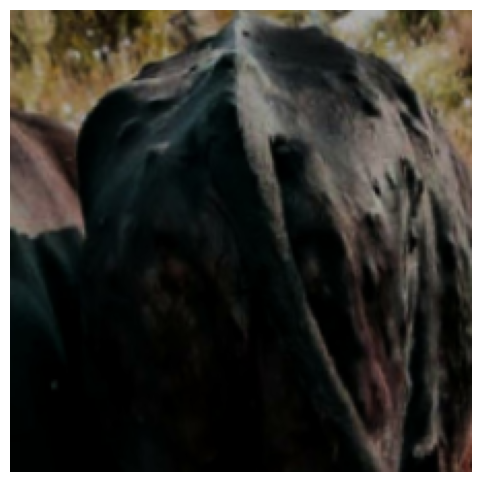

In [14]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    sample_image = images[0]

augmented_image = data_augmentation(tf.expand_dims(sample_image, 0))

plt.figure(figsize=(6,6))
plt.imshow(augmented_image[0])
plt.axis("off")
plt.show()

Build the CNN

In [16]:
from tensorflow.keras import models, layers

cnn_model = models.Sequential([

    # Data augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(3, activation='softmax')
])

In [17]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (1, 52, 52, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (1, 26, 26, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 128)               │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 3)                 │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

train model

In [19]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 442s 6s/step - accuracy: 0.5201 - loss: 1.0148 - val_accuracy: 0.6660 - val_loss: 0.8007
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.6496 - loss: 0.8071 - val_accuracy: 0.7093 - val_loss: 0.6813
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 306s 4s/step - accuracy: 0.6800 - loss: 0.7354 - val_accuracy: 0.7340 - val_loss: 0.6909
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 341s 5s/step - accuracy: 0.6915 - loss: 0.7086 - val_accuracy: 0.7299 - val_loss: 0.6629
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 310s 4s/step - accuracy: 0.7171 - loss: 0.6843 - val_accuracy: 0.7402 - val_loss: 0.6580
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 321s 5s/step - accuracy: 0.7175 - loss: 0.6775 - val_accuracy: 0.7402 - val_loss: 0.6763
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 309s 4s/step - accuracy: 0.7294 - loss: 0.6641 - val_accuracy: 0.7320 - val_loss: 0.7043
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 319s 4s/step - accuracy: 0.7215 - loss: 0.6551 - val_accuracy: 0.7361 - v

In [20]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.7525 - loss: 0.8063
Test Loss: 0.8063322901725769
Test Accuracy: 0.7524752616882324


Accuracy and Loss Curves

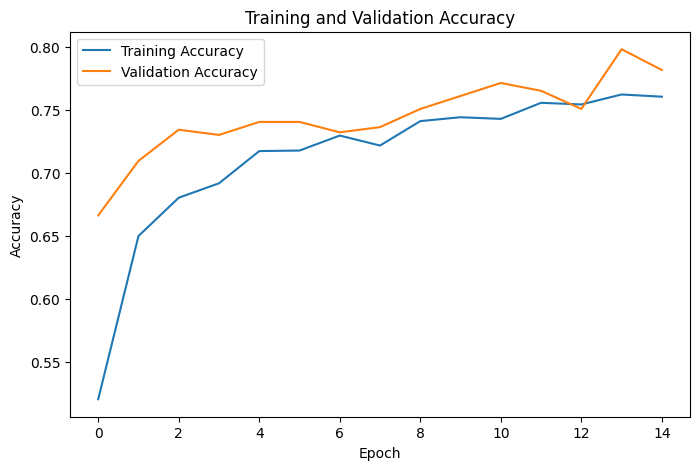

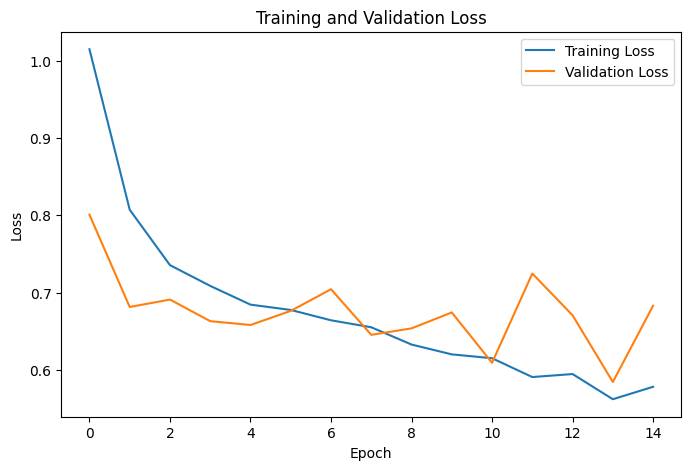

In [21]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

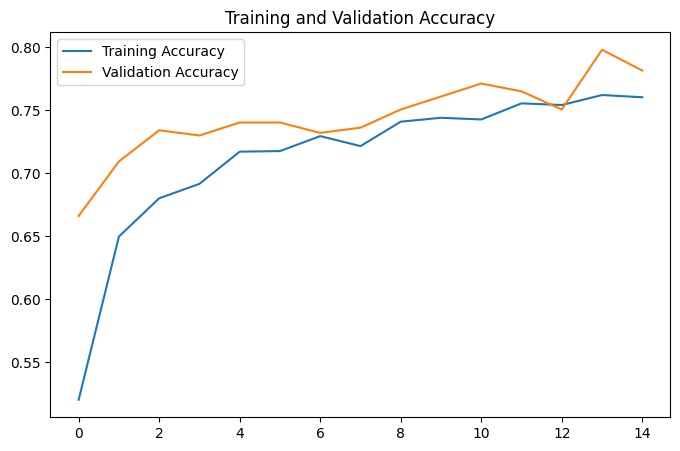

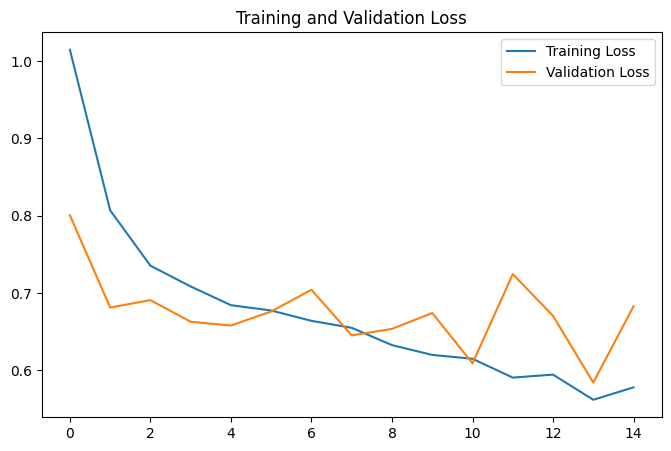

In [22]:
# Accuracy Figure
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.savefig("cnn_accuracy_curve.png")
plt.show()

# Loss Figure
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.savefig("cnn_loss_curve.png")
plt.show()

Confusion Matrix and Classification Report

In [23]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

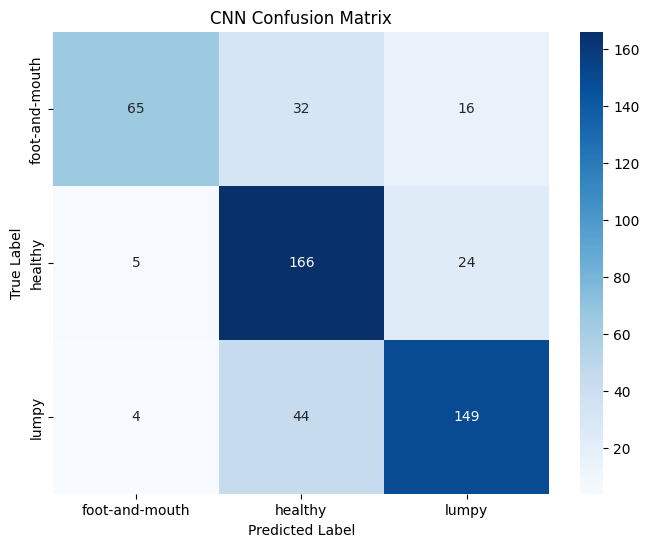

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")
plt.show()

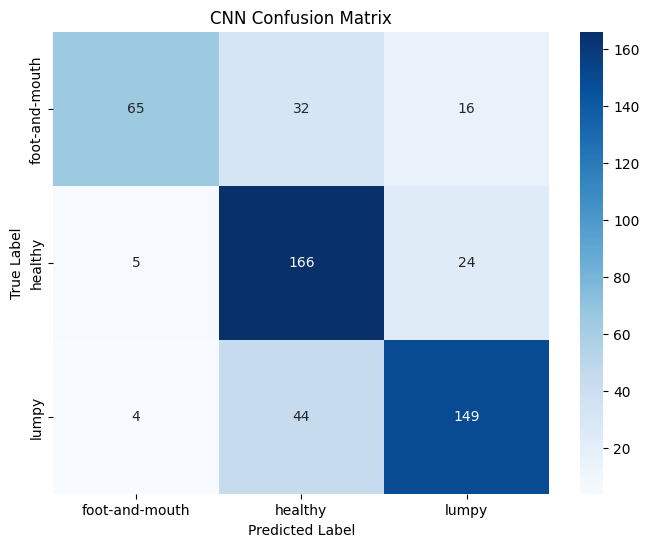

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.savefig("cnn_confusion_matrix.png")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                precision    recall  f1-score   support

foot-and-mouth       0.88      0.58      0.70       113
       healthy       0.69      0.85      0.76       195
         lumpy       0.79      0.76      0.77       197

      accuracy                           0.75       505
     macro avg       0.78      0.73      0.74       505
  weighted avg       0.77      0.75      0.75       505



In [27]:
cnn_model.save('/content/drive/MyDrive/ml_project/custom_cnn.keras')

# Transfer Learning Using MobileNetV2

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

Load the Pretrained Base Model

In [29]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build the Transfer Learning Model

In [30]:
mobilenet_model = models.Sequential([

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(3, activation='softmax')
])

In [32]:
mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
mobilenet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 7, 7, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 128)               │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 3)                 │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# MobileNetV2 Training

In [34]:
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.7382 - loss: 0.6457 - val_accuracy: 0.8722 - val_loss: 0.3561
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.8444 - loss: 0.4000 - val_accuracy: 0.8598 - val_loss: 0.3535
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8629 - loss: 0.3547 - val_accuracy: 0.9093 - val_loss: 0.2665
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.8832 - loss: 0.3285 - val_accuracy: 0.9093 - val_loss: 0.2535
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.8850 - loss: 0.2977 - val_accuracy: 0.9093 - val_loss: 0.2600
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8942 - loss: 0.2706 - val_accuracy: 0.9010 - val_loss: 0.2616
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9017 - loss: 0.2593 - val_accuracy: 0.9093 - val_loss: 0.2447
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 181s 3s/step - accuracy: 0.9039 - loss: 0.2477 - val_accuracy: 0.9196 - v

In [35]:
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(test_ds)

print("MobileNetV2 Test Loss:", mobilenet_test_loss)
print("MobileNetV2 Test Accuracy:", mobilenet_test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8812 - loss: 0.2915
MobileNetV2 Test Loss: 0.29149121046066284
MobileNetV2 Test Accuracy: 0.8811880946159363


In [36]:
y_true_mobilenet = []
y_pred_mobilenet = []

for images, labels in test_ds:
    predictions = mobilenet_model.predict(images, verbose=0)

    y_true_mobilenet.extend(labels.numpy())
    y_pred_mobilenet.extend(np.argmax(predictions, axis=1))

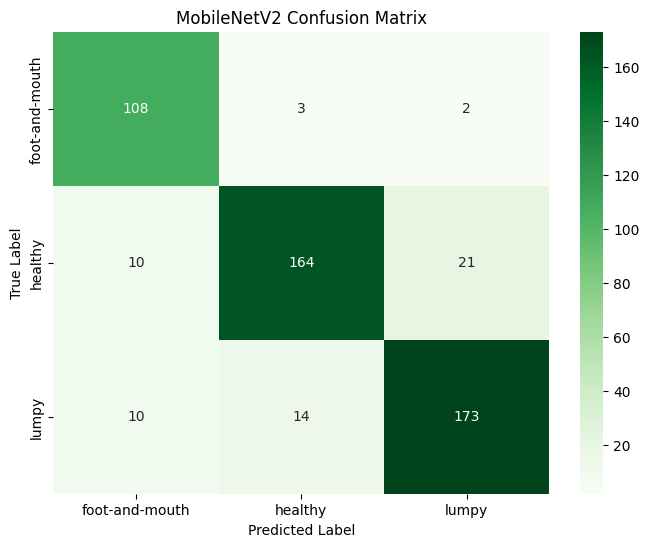

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_mobilenet = confusion_matrix(
    y_true_mobilenet,
    y_pred_mobilenet
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_mobilenet,
        y_pred_mobilenet,
        target_names=class_names
    )
)

                precision    recall  f1-score   support

foot-and-mouth       0.84      0.96      0.90       113
       healthy       0.91      0.84      0.87       195
         lumpy       0.88      0.88      0.88       197

      accuracy                           0.88       505
     macro avg       0.88      0.89      0.88       505
  weighted avg       0.88      0.88      0.88       505



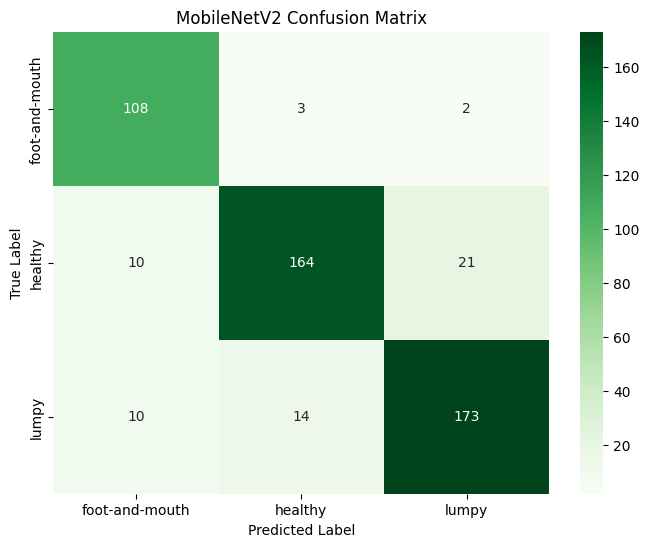

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")

plt.savefig("mobilenet_confusion_matrix.png")
plt.show()

# MobileNetV2 Accuracy and Loss Curves

In [40]:
acc = mobilenet_history.history['accuracy']
val_acc = mobilenet_history.history['val_accuracy']

loss = mobilenet_history.history['loss']
val_loss = mobilenet_history.history['val_loss']

epochs_range = range(len(acc))

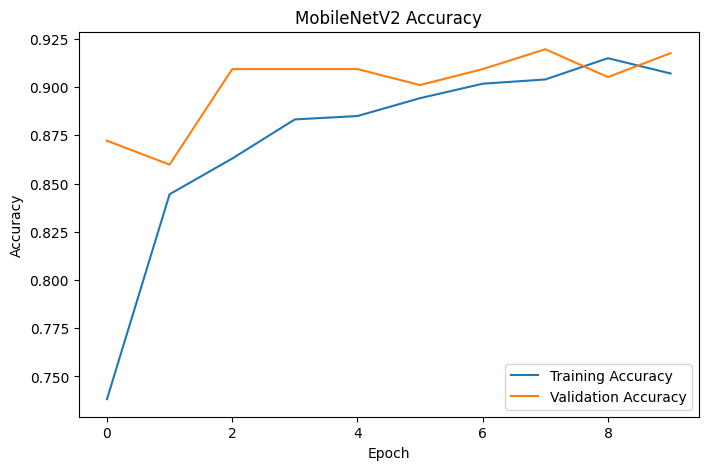

In [41]:
plt.figure(figsize=(8,5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.savefig("mobilenet_accuracy_curve.png")
plt.show()

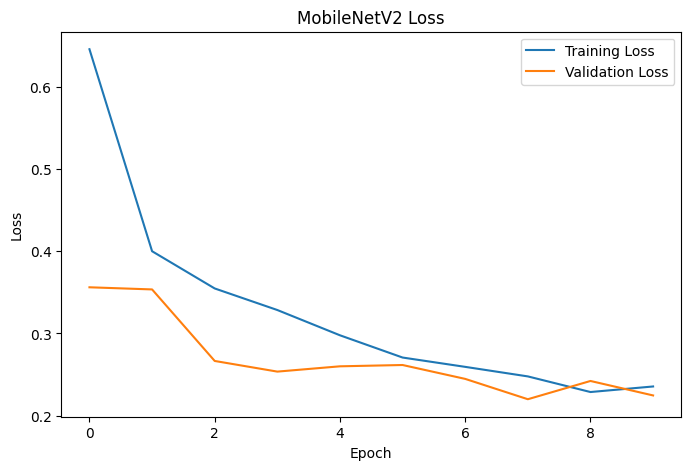

In [42]:
plt.figure(figsize=(8,5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.savefig("mobilenet_loss_curve.png")
plt.show()

# Model Comparison

In [43]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [75.25, 88.12]
})

comparison

,Model,Test Accuracy
0,Custom CNN,75.25
1,MobileNetV2,88.12
